In [54]:
import pandas as pd

df = pd.read_csv(
    "DOHMH_New_York_City_Restaurant_Inspection_Results_20260412.csv",
    engine="python",
    on_bad_lines="skip"
)

df.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50134842,THE MIGRANT KITCHEN,Manhattan,1802,E 65 ST,NaN,9174824644,NaN,01/01/1900,NaN,...,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN
1,50173648,SUSHI DOKORO MEKUMI,Manhattan,70,CHARLTON STREET,10014.0,2129251613,NaN,01/01/1900,NaN,...,NaN,40.727239,-74.006559,102.0,3.0,3700.0,1090545.0,1.005800e+09,MN24,POINT (-74.006559232767 40.727239355189)
2,50174755,WENDYS,Manhattan,111,FULTON STREET,10038.0,7186197481,NaN,01/01/1900,NaN,...,NaN,40.709741,-74.006792,101.0,1.0,1501.0,1001263.0,1.000918e+09,MN25,POINT (-74.006791958532 40.709741446444)
3,50171783,THE MORGAN,Brooklyn,2,KNICKERBOCKER AVENUE,11237.0,9175602894,NaN,01/01/1900,NaN,...,NaN,40.707679,-73.931992,301.0,34.0,45300.0,3070605.0,3.029910e+09,BK77,POINT (-73.931992345105 40.707679371791)
4,50182694,Ool Holdings LLC,Manhattan,178,SPRING STREET,10012.0,6096104773,NaN,01/01/1900,NaN,...,NaN,40.724788,-74.002464,102.0,1.0,4700.0,1007329.0,1.004880e+09,MN24,POINT (-74.002464131233 40.724788439974)


In [55]:
df.shape
df.columns.tolist()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295748 entries, 0 to 295747
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  295748 non-null  int64  
 1   DBA                    295747 non-null  object 
 2   BORO                   295748 non-null  object 
 3   BUILDING               294761 non-null  object 
 4   STREET                 295742 non-null  object 
 5   ZIPCODE                292590 non-null  float64
 6   PHONE                  295669 non-null  object 
 7   CUISINE DESCRIPTION    292203 non-null  object 
 8   INSPECTION DATE        295748 non-null  object 
 9   ACTION                 292253 non-null  object 
 10  VIOLATION CODE         289934 non-null  object 
 11  VIOLATION DESCRIPTION  289934 non-null  object 
 12  CRITICAL FLAG          295748 non-null  object 
 13  SCORE                  278843 non-null  float64
 14  GRADE                  145707 non-nu

In [56]:
df["CUISINE DESCRIPTION"].value_counts().head(30)

,count
CUISINE DESCRIPTION,
American,45376
Chinese,29027
Coffee/Tea,21324
Pizza,17228
Latin American,14364
Mexican,12188
Bakery Products/Desserts,11460
Caribbean,11035
Japanese,10443


In [57]:
import pandas as pd
import numpy as np

df = df.copy()

# keep useful rows
df = df[df["BORO"].notna()]
df = df[df["CUISINE DESCRIPTION"].notna()]
df = df[df["INSPECTION DATE"].notna()]
df = df[df["BORO"] != "0"]

# parse date
df["INSPECTION DATE"] = pd.to_datetime(df["INSPECTION DATE"], errors="coerce")
df = df[df["INSPECTION DATE"].notna()]

# year
df["YEAR"] = df["INSPECTION DATE"].dt.year

# score numeric
df["SCORE"] = pd.to_numeric(df["SCORE"], errors="coerce")

# keep top cuisines
top_cuisines = df["CUISINE DESCRIPTION"].value_counts().head(10).index
df["CUISINE_GROUP"] = df["CUISINE DESCRIPTION"].apply(
    lambda x: x if x in top_cuisines else "Other"
)

# one row per inspection
inspection_df = df.drop_duplicates(subset=["CAMIS", "INSPECTION DATE"]).copy()

print(df.shape)
print(inspection_df.shape)

(291924, 29)
(84350, 29)


In [58]:
def recode_cuisine(x):
    if x == "American":
        return "American"
    elif x == "Chinese":
        return "Chinese"
    elif x in ["Italian", "Pizza"]:
        return "Italian"
    elif x == "Japanese":
        return "Japanese"
    elif x == "Korean":
        return "Korean"
    elif x == "Thai":
        return "Thai"
    elif x in ["Mexican", "Tex-Mex"]:
        return "Mexican"
    elif x in ["Latin American", "Spanish"]:
        return "Latin American"
    elif x == "Caribbean":
        return "Caribbean"
    elif x == "Indian":
        return "Indian"
    elif x == "Asian/Asian Fusion":
        return "Asian Fusion"
    else:
        return "Other"

In [59]:
df["CUISINE_CLEAN"] = df["CUISINE DESCRIPTION"].apply(recode_cuisine)

In [60]:
print("Violation rows:", len(df))
print("Unique inspections:", len(inspection_df))
print("Unique restaurants:", inspection_df["CAMIS"].nunique())

Violation rows: 291924
Unique inspections: 84350
Unique restaurants: 27409


In [61]:
def apply_filters(data, boroughs=None, cuisines=None, years=None, grades=None):
    filtered = data.copy()

    if boroughs and "All" not in boroughs:
        filtered = filtered[filtered["BORO"].isin(boroughs)]

    if cuisines and "All" not in cuisines:
        filtered = filtered[filtered["CUISINE_CLEAN"].isin(cuisines)]

    if years and "All" not in years:
        filtered = filtered[filtered["YEAR"].isin(years)]

    if grades and "All" not in grades and "GRADE" in filtered.columns:
        filtered = filtered[filtered["GRADE"].isin(grades)]

    return filtered

In [62]:
def summarize_by_borough(inspection_df, violation_df, metric):
    if metric == "Avg Score":
        return (
            inspection_df.groupby("BORO")["SCORE"]
            .mean()
            .reset_index(name="value")
        )

    elif metric == "Restaurant Count":
        return (
            inspection_df.groupby("BORO")["CAMIS"]
            .nunique()
            .reset_index(name="value")
        )

    elif metric == "Inspection Count":
        return (
            inspection_df.groupby("BORO")
            .size()
            .reset_index(name="value")
        )

    elif metric == "Violation Count":
        return (
            violation_df.groupby("BORO")
            .size()
            .reset_index(name="value")
        )

    elif metric == "Grade A %":
        temp = inspection_df.copy()
        temp["is_A"] = (temp["GRADE"] == "A").astype(int)
        return (
            temp.groupby("BORO")["is_A"]
            .mean()
            .reset_index(name="value")
        )

    else:
        raise ValueError("Unknown metric")

In [63]:
def summarize_by_cuisine(inspection_df, violation_df, metric):
    if metric == "Avg Score":
        return (
            inspection_df.groupby("CUISINE_CLEAN")["SCORE"]
            .mean()
            .reset_index(name="value")
            .sort_values("value")
        )

    elif metric == "Restaurant Count":
        return (
            inspection_df.groupby("CUISINE_CLEAN")["CAMIS"]
            .nunique()
            .reset_index(name="value")
            .sort_values("value", ascending=False)
        )

    elif metric == "Inspection Count":
        return (
            inspection_df.groupby("CUISINE_CLEAN")
            .size()
            .reset_index(name="value")
            .sort_values("value", ascending=False)
        )

    elif metric == "Violation Count":
        return (
            violation_df.groupby("CUISINE_CLEAN")
            .size()
            .reset_index(name="value")
            .sort_values("value", ascending=False)
        )

    elif metric == "Grade A %":
        temp = inspection_df.copy()
        temp["is_A"] = (temp["GRADE"] == "A").astype(int)
        return (
            temp.groupby("CUISINE_CLEAN")["is_A"]
            .mean()
            .reset_index(name="value")
            .sort_values("value")
        )

    else:
        raise ValueError("Unknown metric")

In [64]:
def make_heatmap_data(inspection_df, violation_df, metric):
    if metric == "Avg Score":
        return inspection_df.groupby(["BORO", "CUISINE_CLEAN"])["SCORE"].mean().unstack()

    elif metric == "Restaurant Count":
        return inspection_df.groupby(["BORO", "CUISINE_CLEAN"])["CAMIS"].nunique().unstack()

    elif metric == "Inspection Count":
        return inspection_df.groupby(["BORO", "CUISINE_CLEAN"]).size().unstack()

    elif metric == "Violation Count":
        return violation_df.groupby(["BORO", "CUISINE_CLEAN"]).size().unstack()

    elif metric == "Grade A %":
        temp = inspection_df.copy()
        temp["is_A"] = (temp["GRADE"] == "A").astype(int)
        return temp.groupby(["BORO", "CUISINE_CLEAN"])["is_A"].mean().unstack()

    else:
        raise ValueError("Unknown metric")

In [65]:
selected_boroughs = ["All"]
selected_cuisines = ["All"]
selected_years = ["All"]
metric = "Avg Score"

filtered_violation_df = apply_filters(
    df,
    boroughs=selected_boroughs,
    cuisines=selected_cuisines,
    years=selected_years
)

filtered_inspection_df = filtered_violation_df.drop_duplicates(subset=["CAMIS", "INSPECTION DATE"]).copy()

print(filtered_violation_df.shape)
print(filtered_inspection_df.shape)

(291924, 30)
(84350, 30)


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

chart1: Borough Inspection Performance Relative to City Average

In [67]:
import pandas as pd
import numpy as np

df['SCORE'] = pd.to_numeric(df['SCORE'], errors='coerce')

score_df = df.dropna(subset=['BORO', 'SCORE']).copy()

borough_perf = (
    score_df.groupby('BORO', as_index=False)
    .agg(
        avg_score=('SCORE', 'mean'),
        n=('SCORE', 'size')
    )
)

In [68]:
city_avg = score_df['SCORE'].mean()

borough_perf['diff_from_city'] = borough_perf['avg_score'] - city_avg

In [69]:
borough_perf['BORO'] = borough_perf['BORO'].replace({
    'BRONX': 'Bronx',
    'BROOKLYN': 'Brooklyn',
    'MANHATTAN': 'Manhattan',
    'QUEENS': 'Queens',
    'STATEN ISLAND': 'Staten Island'
})

In [70]:
borough_perf = borough_perf.sort_values('diff_from_city')

borough_perf['performance'] = np.where(
    borough_perf['diff_from_city'] <= 0,
    'Better than average',
    'Worse than average'
)

In [71]:
import altair as alt

chart = alt.Chart(borough_perf).mark_bar().encode(
    x=alt.X('BORO:N', sort=None, title=''),
    y=alt.Y('diff_from_city:Q', title='Difference from city average score'),
    color=alt.Color(
        'performance:N',
        scale=alt.Scale(
            domain=['Better than average', 'Worse than average'],
            range=['#22c55e', '#ef4444']
        ),
        legend=alt.Legend(title=None)
    ),
    tooltip=[
        alt.Tooltip('BORO:N', title='Borough'),
        alt.Tooltip('avg_score:Q', title='Avg Score', format='.2f'),
        alt.Tooltip('diff_from_city:Q', title='Difference', format='.2f'),
        alt.Tooltip('n:Q', title='Inspections')
    ]
).properties(
    width=500,
    height=350,
    title='Borough Inspection Performance Relative to City Average'
)

rule = alt.Chart(pd.DataFrame({'y': [0]})).mark_rule(color='gray').encode(y='y:Q')

chart + rule

alt.LayerChart(...)

Key Takeaway:

Inspection performance varies noticeably across boroughs relative to the city average. Staten Island and the Bronx perform better than average, showing lower violation scores, while Queens and Brooklyn exhibit worse-than-average performance, indicating higher inspection risk. Manhattan sits closer to the city average, suggesting more moderate inspection outcomes compared to other boroughs.

chart 1: Average Inspection Score by Cuisine

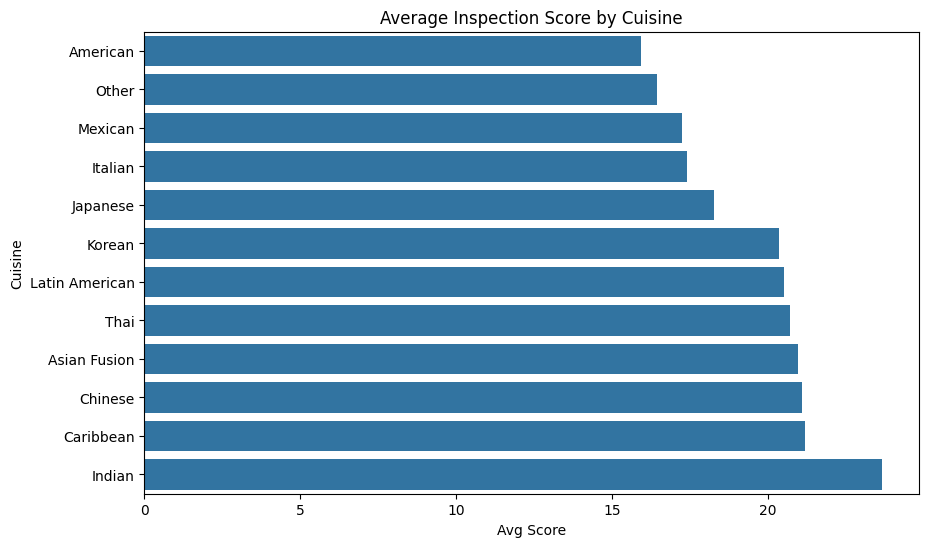

In [72]:
cuisine_summary = summarize_by_cuisine(filtered_inspection_df, filtered_violation_df, metric)

plt.figure(figsize=(10, 6))
sns.barplot(data=cuisine_summary, x="value", y="CUISINE_CLEAN")
plt.title("Average Inspection Score by Cuisine")
plt.xlabel(metric)
plt.ylabel("Cuisine")
plt.show()

Key Takeaway:

Inspection outcomes differ noticeably across cuisine types. Indian and Caribbean cuisines have the highest average inspection scores, indicating higher violation levels, while American cuisine shows the lowest average score and better overall performance. Most other cuisines fall in a middle range, suggesting moderate inspection outcomes across categories.

chart 3: borough-cuisine heatmap

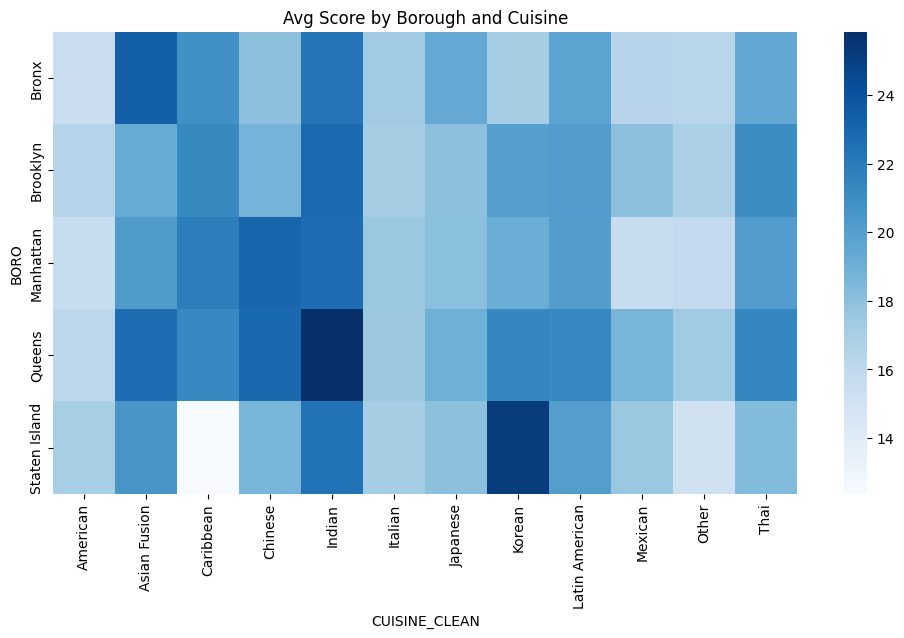

In [73]:
heatmap_data = make_heatmap_data(filtered_inspection_df, filtered_violation_df, metric)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="Blues", annot=False)
plt.title(f"{metric} by Borough and Cuisine")
plt.show()

Key Takeaway:

Inspection performance varies across both borough and cuisine, with noticeable differences within the same cuisine depending on location. For example, Indian cuisine shows consistently high scores across boroughs, especially in Queens, while some cuisines such as American and Italian remain relatively lower across most areas. This suggests that inspection outcomes are shaped by a combination of cuisine type and geographic location.

chart 4: Most common violations across Borough

In [74]:
import pandas as pd
import numpy as np

viol_df = df.copy()

viol_df = viol_df[['BORO', 'VIOLATION DESCRIPTION']].copy()

viol_df = viol_df.dropna(subset=['BORO', 'VIOLATION DESCRIPTION'])

viol_df['BORO'] = viol_df['BORO'].astype(str).str.strip().str.title()

valid_boroughs = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']
viol_df = viol_df[viol_df['BORO'].isin(valid_boroughs)]

viol_df['VIOLATION DESCRIPTION'] = (
    viol_df['VIOLATION DESCRIPTION']
    .astype(str)
    .str.strip()
)

In [75]:
top_violations = (
    viol_df['VIOLATION DESCRIPTION']
    .value_counts()
    .head(10)
    .index
)

top_violations

Index(['Non-food contact surface or equipment made of unacceptable material, not kept clean, or not properly sealed, raised, spaced or movable to allow accessibility for cleaning on all sides, above and underneath the unit.',
       'Establishment is not free of harborage or conditions conducive to rodents, insects or other pests.',
       'Food contact surface not properly washed, rinsed and sanitized after each use and following any activity when contamination may have occurred.',
       'Anti-siphonage or back-flow prevention device not provided where required; equipment or floor not properly drained; sewage disposal system in disrepair or not functioning properly. Condensation or liquid waste improperly disposed of.',
       'Cold TCS food item held above 41 °F; smoked or processed fish held above 38 °F; intact raw eggs held above 45 °F; or reduced oxygen packaged (ROP) TCS foods held above required temperatures except during active necessary preparation.',
       'Food, supplies, 

In [76]:
viol_top = viol_df[viol_df['VIOLATION DESCRIPTION'].isin(top_violations)].copy()

borough_violation = pd.crosstab(
    viol_top['VIOLATION DESCRIPTION'],
    viol_top['BORO']
)

borough_violation

BORO,Bronx,Brooklyn,Manhattan,Queens,Staten Island
VIOLATION DESCRIPTION,,,,,
Anti-siphonage or back-flow prevention device not provided where required; equipment or floor not properly drained; sewage disposal system in disrepair or not functioning properly. Condensation or liquid waste improperly disposed of.,1882,4319,6948,4164,479
Cold TCS food item held above 41 °F; smoked or processed fish held above 38 °F; intact raw eggs held above 45 °F; or reduced oxygen packaged (ROP) TCS foods held above required temperatures except during active necessary preparation.,1589,4377,6707,4267,651
"Establishment is not free of harborage or conditions conducive to rodents, insects or other pests.",2549,6648,8910,6168,826
Evidence of mice or live mice in establishment's food or non-food areas.,1469,3945,4787,3592,525
"Filth flies or food/refuse/sewage associated with (FRSA) flies or other nuisance pests in establishment’s food and/or non-food areas. FRSA flies include house flies, blow flies, bottle flies, flesh flies, drain flies, Phorid flies and fruit flies.",805,2299,3542,2038,283
Food Protection Certificate (FPC) not held by manager or supervisor of food operations.,831,2137,2300,2058,329
"Food contact surface not properly washed, rinsed and sanitized after each use and following any activity when contamination may have occurred.",1335,4611,7662,4231,803
"Food, supplies, or equipment not protected from potential source of contamination during storage, preparation, transportation, display, service or from customer’s refillable, reusable container. Condiments not in single-service containers or dispensed directly by the vendor.",1054,3742,5556,4457,459
Hot TCS food item not held at or above 140 °F.,1740,3865,5015,3815,525


In [77]:
borough_violation_pct = borough_violation.div(
    borough_violation.sum(axis=0),
    axis=1
) * 100

In [78]:
list(borough_violation_pct.index)

['Anti-siphonage or back-flow prevention device not provided where required; equipment or floor not properly drained; sewage disposal system in disrepair or not functioning properly. Condensation or liquid waste improperly disposed of.',
 'Cold TCS food item held above 41 °F; smoked or processed fish held above 38 °F; intact raw eggs held above 45 °F; or reduced oxygen packaged (ROP) TCS foods held above required temperatures except during active necessary preparation.',
 'Establishment is not free of harborage or conditions conducive to rodents, insects or other pests.',
 "Evidence of mice or live mice in establishment's food or non-food areas.",
 'Filth flies or food/refuse/sewage associated with (FRSA) flies or other nuisance pests in establishment’s food and/or non-food areas. FRSA flies include house flies, blow flies, bottle flies, flesh flies, drain flies, Phorid flies and fruit flies.',
 'Food Protection Certificate (FPC) not held by manager or supervisor of food operations.',


In [79]:
label_map = {
    "Anti-siphonage or back-flow prevention device not provided where required; equipment or floor not properly drained; sewage disposal system in disrepair or not functioning properly. Condensation or liquid waste improperly disposed of.": "Plumbing / drainage",

    "Cold TCS food item held above 41 °F; smoked or processed fish held above 38 °F; intact raw eggs held above 45 °F; or reduced oxygen packaged (ROP) TCS foods held above required temperatures except during active necessary preparation.": "Cold food temp",

    "Establishment is not free of harborage or conditions conducive to rodents, insects or other pests.": "Pest conditions",

    "Evidence of mice or live mice in establishment's food or non-food areas.": "Rodent evidence",

    "Filth flies or food/refuse/sewage associated with (FRSA) flies or other nuisance pests in establishment’s food and/or non-food areas. FRSA flies include house flies, blow flies, bottle flies, flesh flies, drain flies, Phorid flies and fruit flies.": "Flies / pests",

    "Food Protection Certificate (FPC) not held by manager or supervisor of food operations.": "No FPC",

    "Food contact surface not properly washed, rinsed and sanitized after each use and following any activity when contamination may have occurred.": "Surface sanitation",

    "Food, supplies, or equipment not protected from potential source of contamination during storage, preparation, transportation, display, service or from customer’s refillable, reusable container. Condiments not in single-service containers or dispensed directly by the vendor.": "Improper protection",

    "Hot TCS food item not held at or above 140 °F.": "Hot food temp",

    "Non-food contact surface or equipment made of unacceptable material, not kept clean, or not properly sealed, raised, spaced or movable to allow accessibility for cleaning on all sides, above and underneath the unit.": "Non-food surface(cleanliness)"
}

In [80]:
for v in borough_violation_pct.index:
    print(repr(v))
    print("-" * 80)

'Anti-siphonage or back-flow prevention device not provided where required; equipment or floor not properly drained; sewage disposal system in disrepair or not functioning properly. Condensation or liquid waste improperly disposed of.'
--------------------------------------------------------------------------------
'Cold TCS food item held above 41 °F; smoked or processed fish held above 38 °F; intact raw eggs held above 45 °F; or reduced oxygen packaged (ROP) TCS foods held above required temperatures except during active necessary preparation.'
--------------------------------------------------------------------------------
'Establishment is not free of harborage or conditions conducive to rodents, insects or other pests.'
--------------------------------------------------------------------------------
"Evidence of mice or live mice in establishment's food or non-food areas."
--------------------------------------------------------------------------------
'Filth flies or food/refuse/

In [81]:
unmatched = [v for v in borough_violation_pct.index if v not in label_map]
unmatched

[]

In [82]:
borough_violation_pct_short = borough_violation_pct.copy()

borough_violation_pct_short.index = [
    label_map.get(v, v) for v in borough_violation_pct_short.index
]

borough_violation_pct_short

BORO,Bronx,Brooklyn,Manhattan,Queens,Staten Island
Plumbing / drainage,10.881129,9.478767,10.493566,9.427000,7.598350
Cold food temp,9.187095,9.606057,10.129584,9.660184,10.326777
Pest conditions,14.737512,14.590146,13.456775,13.963913,13.102792
Rodent evidence,8.493293,8.657961,7.229807,8.132032,8.328046
Flies / pests,4.654255,5.045539,5.349483,4.613887,4.489213
No FPC,4.804579,4.690003,3.473691,4.659166,5.218909
Surface sanitation,7.718548,10.119609,11.571920,9.578683,12.737944
Improper protection,6.093895,8.212444,8.391228,10.090331,7.281091
Hot food temp,10.060130,8.482388,7.574156,8.636888,8.328046
Non-food surface(cleanliness),23.369565,21.117085,22.329789,21.237916,22.588832


In [83]:
borough_violation_pct_short = borough_violation_pct_short.loc[
    borough_violation_pct_short.mean(axis=1).sort_values(ascending=False).index
]

In [84]:
borough_order = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']

borough_violation_pct_short = borough_violation_pct_short[borough_order]

In [85]:
print(borough_violation_pct_short.columns.tolist())

['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']


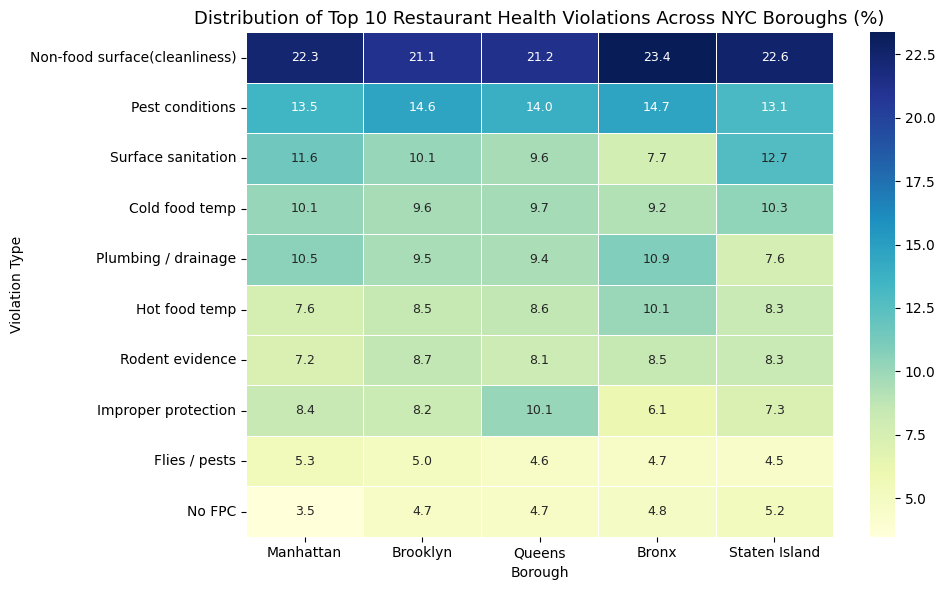

In [86]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    borough_violation_pct_short,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    annot_kws={"size": 9}
)

plt.title('Distribution of Top 10 Restaurant Health Violations Across NYC Boroughs (%)', fontsize=13)
plt.xlabel('Borough')
plt.ylabel('Violation Type')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Key Takeaway:

The distribution of violation types is highly consistent across boroughs, with cleanliness and pest-related issues dominating in all areas. This suggests that the observed differences in inspection outcomes across cuisines and boroughs are unlikely to be driven by fundamentally different types of violations. Instead, the variation is more likely explained by differences in how frequently or severely these common issues occur across restaurant types and locations.

Mapping

In [87]:
print(df.columns.tolist())

['CAMIS', 'DBA', 'BORO', 'BUILDING', 'STREET', 'ZIPCODE', 'PHONE', 'CUISINE DESCRIPTION', 'INSPECTION DATE', 'ACTION', 'VIOLATION CODE', 'VIOLATION DESCRIPTION', 'CRITICAL FLAG', 'SCORE', 'GRADE', 'GRADE DATE', 'RECORD DATE', 'INSPECTION TYPE', 'Latitude', 'Longitude', 'Community Board', 'Council District', 'Census Tract', 'BIN', 'BBL', 'NTA', 'Location', 'YEAR', 'CUISINE_GROUP', 'CUISINE_CLEAN']


In [88]:
map_df = df.copy()

map_df = map_df.dropna(subset=[
    'Latitude',
    'Longitude',
    'BORO',
    'DBA',
    'CUISINE DESCRIPTION',
    'CRITICAL FLAG'
]).copy()

map_df = map_df[
    (map_df['Latitude'] != 0) &
    (map_df['Longitude'] != 0)
].copy()

map_df['BORO'] = map_df['BORO'].astype(str).str.strip().str.title()
map_df['CRITICAL FLAG'] = map_df['CRITICAL FLAG'].astype(str).str.strip()
map_df['DBA'] = map_df['DBA'].astype(str).str.strip()
map_df['CUISINE DESCRIPTION'] = map_df['CUISINE DESCRIPTION'].astype(str).str.strip()

In [89]:
print(map_df['CRITICAL FLAG'].value_counts(dropna=False))

CRITICAL FLAG
Critical          153370
Not Critical      130214
Not Applicable      4082
Name: count, dtype: int64


In [90]:
map_df['is_critical'] = (map_df['CRITICAL FLAG'] == 'Critical').astype(int)

In [91]:
risk_map = (
    map_df.groupby(
        ['DBA', 'BORO', 'CUISINE DESCRIPTION', 'Latitude', 'Longitude'],
        as_index=False
    )
    .agg(
        critical_violation_count=('is_critical', 'sum'),
        total_records=('is_critical', 'size')
    )
)

In [92]:
risk_map = risk_map[risk_map['critical_violation_count'] > 0].copy()

In [93]:
risk_map['critical_violation_rate'] = (
    risk_map['critical_violation_count'] / risk_map['total_records']
)

In [94]:
risk_map_filtered = risk_map.copy()

In [95]:
upper = risk_map_filtered['critical_violation_rate'].quantile(0.95)

risk_map_filtered['rate_capped'] = (
    risk_map_filtered['critical_violation_rate'].clip(upper=upper)
)

In [96]:
selected_cuisine = 'All'
selected_boro = 'All'
min_rate = 0.0

plot_df = risk_map_filtered.copy()

if selected_cuisine != 'All':
    plot_df = plot_df[plot_df['CUISINE DESCRIPTION'] == selected_cuisine].copy()

if selected_boro != 'All':
    plot_df = plot_df[plot_df['BORO'] == selected_boro].copy()

plot_df = plot_df[plot_df['critical_violation_rate'] >= min_rate].copy()

print("plot_df rows:", len(plot_df))

plot_df rows: 25788


In [97]:
import plotly.express as px

fig = px.scatter_mapbox(
    plot_df,
    lat='Latitude',
    lon='Longitude',
    color='rate_capped',
    color_continuous_scale='OrRd',
    hover_name='DBA',
    hover_data={
        'BORO': True,
        'CUISINE DESCRIPTION': True,
        'critical_violation_count': True,
        'total_records': True,
        'critical_violation_rate': ':.2f',
        'Latitude': False,
        'Longitude': False
    },
    zoom=10,
    height=650,
    opacity=0.30,
    title='Spatial Distribution of Restaurant-Level Critical Violation Risk in NYC'
)

fig.update_layout(mapbox_style='carto-positron')
fig.update_traces(marker=dict(size=5))
fig.update_coloraxes(colorbar_title='Critical violation rate')
fig.show()

Key Takeaway:

The spatial distribution of restaurant-level critical violation risk in NYC shows clear clustering rather than random dispersion. High-risk restaurants are concentrated in specific areas—particularly in parts of Manhattan and Brooklyn—indicating that inspection outcomes are geographically uneven. By using a normalized rate instead of raw counts, the map highlights true risk intensity rather than restaurant density. When considered alongside earlier findings on cuisine and borough differences, this pattern suggests that inspection performance is shaped by a combination of location and restaurant characteristics, rather than a single factor. Areas with consistently higher risk may reflect underlying structural factors such as higher restaurant density, operational pressure, or local conditions that affect compliance.